**Autor:** Andrés Alejandro Rodríguez Lozano  
**Portafolio:** Portafolio de Andrés Alejandro Rodríguez Lozano

# Capítulo 1 — Datos (ETL)

Precios ajustados → series mensuales → retornos. Ventana ene-2016 → sep-2026.

- Precio ajustado ≈ total return.
- $R_t = P_t/P_{t-1}-1$


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({
    'figure.dpi': 72,
    'savefig.dpi': 72,
    'figure.figsize': (8, 3.8),
    'font.size': 9,
    'svg.fonttype': 'none',
    'path.simplify': True,
    'path.simplify_threshold': 0.2,
})

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
import portfolio_utils as pu

def load_monthly():
    """Carga precios mensuales: cache mensual, diario, o yfinance."""
    mpath = ROOT / 'data' / 'precios_mensuales.csv'
    if mpath.exists():
        print('Precios mensuales (cache):', mpath.name)
        return pd.read_csv(mpath, index_col=0, parse_dates=True).loc[: '2026-09-30']
    csv = ROOT / 'data' / 'precios_ajustados_diarios.csv'
    if csv.exists():
        daily = pd.read_csv(csv, index_col=0, parse_dates=True)
        print('Precios diarios (cache):', csv.name)
        return pu.to_month_end(daily).loc[: '2026-09-30']
    tickers = sorted(set(list(pu.CURRENT_WEIGHTS) + [pu.BENCHMARK]))
    print('Descargando precios con yfinance…')
    daily = pu.download_prices(tickers)
    return pu.to_month_end(daily).loc[: '2026-09-30']


monthly = load_monthly()
print(monthly.index.min().date(), '→', monthly.index.max().date(), '| meses:', len(monthly))
rets = monthly.pct_change().loc['2016-01-31':'2026-09-30']
print('Retornos shape:', rets.shape)
rf_path = ROOT / 'data' / 'rf_mensual.csv'
if rf_path.exists():
    rf = pd.read_csv(rf_path, index_col=0, parse_dates=True).squeeze()
else:
    rf = pu.load_risk_free_monthly()
print('RF media mensual (~T-Bill):', round(float(rf.mean()) * 100, 4), '%')


Precios mensuales (cache): precios_mensuales.csv
2015-11-30 → 2026-09-30 | meses: 131
Retornos shape: (129, 6)
RF media mensual (~T-Bill): 0.1889 %


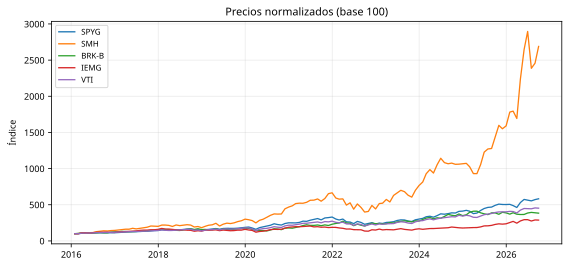

In [2]:
# Gráfico: precios normalizados (base 100) — matplotlib sobre datos reales
norm = monthly.loc['2016-01-31':, list(pu.CURRENT_WEIGHTS)].dropna()
norm = norm / norm.iloc[0] * 100
fig, ax = plt.subplots()
for col in norm.columns:
    ax.plot(norm.index, norm[col], label=col, lw=1.3)
ax.set_title('Precios normalizados (base 100)')
ax.set_ylabel('Índice')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## Conclusiones
1. ETL reproducible vía `portfolio_utils` (cache diario o descarga).
2. Frecuencia mensual alineada con el backtest educativo.

## Ejercicios
1. Compara IEMG vs SPYG en 2022–2023.
2. Correlación VTI vs SPY.
